In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import optuna
import warnings
warnings.filterwarnings('ignore')  # suppress optuna trial logs for cleaner output


In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)


In [3]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


In [4]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.shape


(60000, 785)

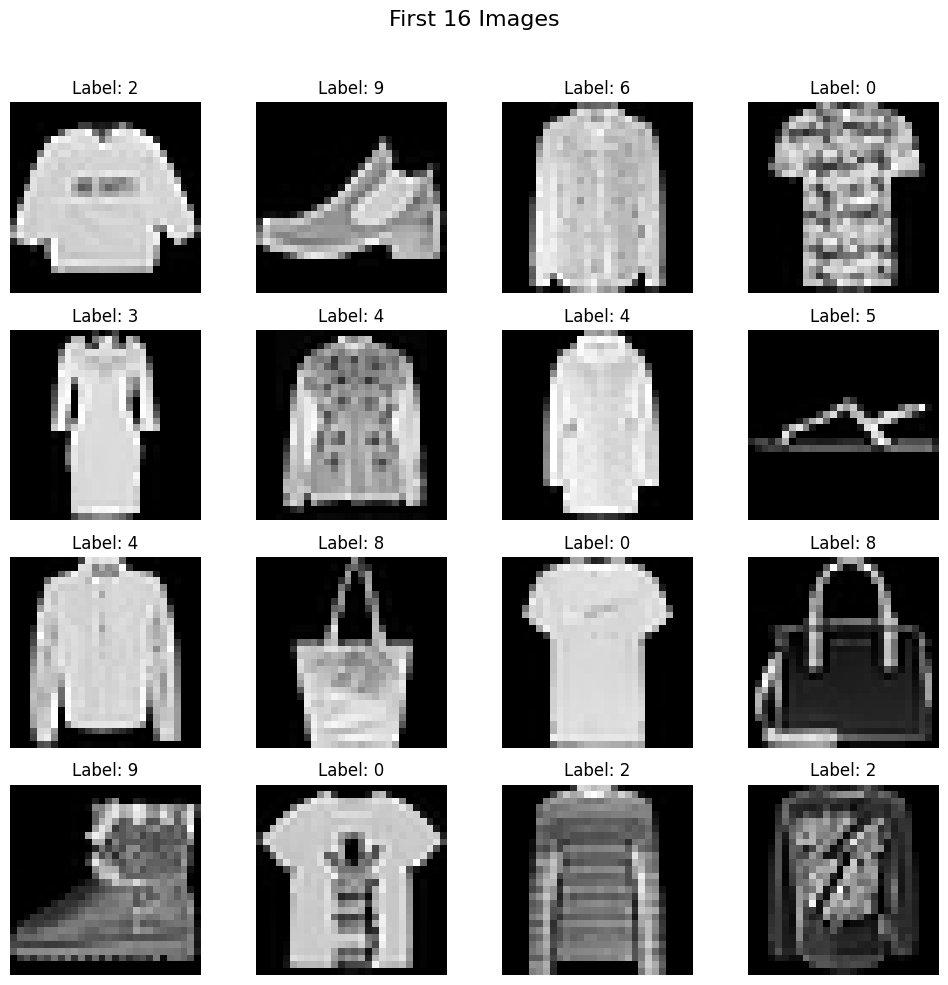

In [6]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('First 16 Images', fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f'Label: {df.iloc[i, 0]}')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [7]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
X_train = X_train / 255.0
X_test  = X_test  / 255.0


In [10]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels   = torch.tensor(labels,   dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]


In [11]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset  = CustomDataset(X_test,  y_test)

print(f'Train samples: {len(train_dataset)}')
print(f'Test  samples: {len(test_dataset)}')


Train samples: 48000
Test  samples: 12000


In [12]:

# Quick sanity check — create a temporary loader to confirm everything works
temp_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
print(f'Batches in train set (batch_size=32): {len(temp_loader)}')
print(f'Each batch has shape: {next(iter(temp_loader))[0].shape}')
del temp_loader  # remove — the real loaders are created inside objective()


Batches in train set (batch_size=32): 1500
Each batch has shape: torch.Size([32, 784])


In [13]:
class MyNN(nn.Module):

    def __init__(self, input_dim, output_dim, num_hidden_layers,
                 neurons_per_layer, dropout_rate):
        super().__init__()

        layers = []

        for i in range(num_hidden_layers):
            layers.append(nn.Linear(input_dim, neurons_per_layer))
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            input_dim = neurons_per_layer  # next layer input = this layer output

        layers.append(nn.Linear(neurons_per_layer, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


In [15]:
def objective(trial):
    # Suggest hyperparameter values for this trial
    num_hidden_layers  = trial.suggest_int('num_hidden_layers', 1, 5)
    neurons_per_layer  = trial.suggest_int('neurons_per_layer', 8, 128, step=8)
    epochs             = trial.suggest_int('epochs', 5, 15, step=5)  # reduced for CPU speed
    learning_rate      = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    dropout_rate       = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
    batch_size         = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    optimizer_name     = trial.suggest_categorical('optimizer', ['Adam', 'SGD', 'RMSprop'])
    weight_decay       = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)

    # DataLoaders (created here so batch_size is tunable)
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True,  pin_memory=False)  # CPU-only: pin_memory must be False
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size,
                              shuffle=False, pin_memory=False)  # CPU-only: pin_memory must be False

    # Model
    model = MyNN(
        input_dim         = 784,
        output_dim        = 10,
        num_hidden_layers = num_hidden_layers,
        neurons_per_layer = neurons_per_layer,
        dropout_rate      = dropout_rate
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(),
                               lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(),
                              lr=learning_rate, weight_decay=weight_decay)
    else:  # RMSprop
        optimizer = optim.RMSprop(model.parameters(),
                                  lr=learning_rate, weight_decay=weight_decay)

    # Training loop
    for epoch in range(epochs):
        model.train()
        for batch_features, batch_labels in train_loader:
            batch_features = batch_features.to(device)
            batch_labels   = batch_labels.to(device)
            optimizer.zero_grad()
            outputs = model(batch_features)
            loss    = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    total   = 0
    correct = 0

    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features = batch_features.to(device)
            batch_labels   = batch_labels.to(device)
            outputs      = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total   += batch_labels.shape[0]
            correct += (predicted == batch_labels).sum().item()

    accuracy = correct / total
    return accuracy

In [16]:
# Create an Optuna study — direction='maximize' because we want highest accuracy
# optuna.logging.set_verbosity suppresses per-trial clutter in the output
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='maximize')
print('Study created. Ready to run trials.')


Study created. Ready to run trials.


In [17]:
# Run Optuna trials — reduced epochs/trials for CPU speed
# n_trials=10 gives a good result without taking too long on CPU
print('Starting Optuna hyperparameter search (this may take a few minutes on CPU)...')

study.optimize(
    objective,
    n_trials=10,          # increase to 20-30 for better results if time allows
    show_progress_bar=True
)

print(f'\nCompleted {len(study.trials)} trials.')
print(f'Best trial accuracy: {study.best_value:.4f}')


Starting Optuna hyperparameter search (this may take a few minutes on CPU)...


  0%|          | 0/10 [00:00<?, ?it/s]


Completed 10 trials.
Best trial accuracy: 0.8712


In [18]:
print('Best hyperparameters found by Optuna:')
for param, value in study.best_params.items():
    print(f'  {param}: {value}')


Best hyperparameters found by Optuna:
  num_hidden_layers: 5
  neurons_per_layer: 112
  epochs: 15
  learning_rate: 1.254625874283814e-05
  dropout_rate: 0.1
  batch_size: 32
  optimizer: RMSprop
  weight_decay: 1.8331794567940934e-05


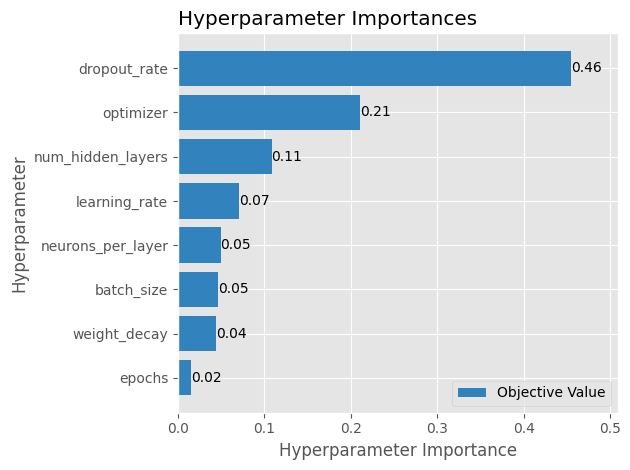

In [19]:
# Show which hyperparameters had the most impact on accuracy
try:
    fig = optuna.visualization.matplotlib.plot_param_importances(study)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Param importance plot needs more trials to be meaningful.')
    print(f'  ({e})')


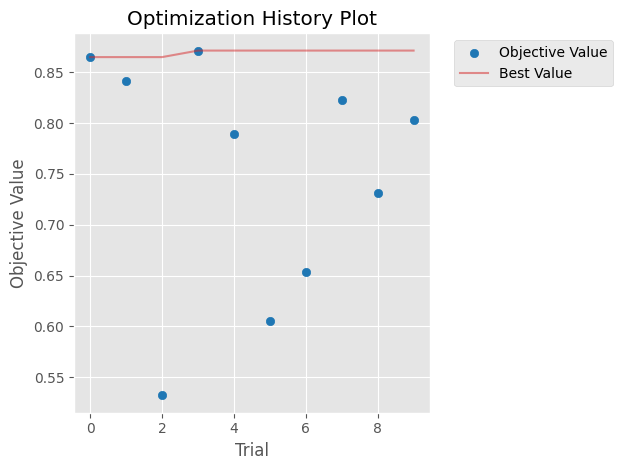

In [20]:
# Plot accuracy across all trials — shows how Optuna improved over time
try:
    fig = optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Optimisation history plot unavailable.')
    print(f'  ({e})')
